# Gemma 4 E4B-itをColabで動かす

Google公式の `google/gemma-4-E4B-it-qat-mobile-transformers` をGoogle Colab上で読み込み、
テキスト・画像・音声・動画を試します。

このNotebookは、書籍のPhi-4 Notebookと同じく、

```text
実行環境の準備
→ Google Drive / cache
→ モデル読み込み
→ 応答生成関数
→ 動作確認
→ Gradio UI
```

という流れにしています。


In [16]:
# =========================================
# コード1 実行環境の準備
# Colab既定PyTorchは変更しない
# =========================================
!nvidia-smi -L || echo "No GPU"
!python -V

# Gemma 4公式例ではtorchaudioは必須ではない。
# ColabでPyTorchとのCUDA不整合を起こすことがあるため削除。
%pip -q uninstall -y torchaudio

# NumPy / SciPyのバイナリ互換性を揃える
%pip -q install --no-cache-dir --force-reinstall \
    "numpy==2.2.6" \
    "scipy==1.16.1"

# Torch / TorchVision / GradioはColab既定版を利用。
# Gemma 4に必要なものだけ追加・更新。
%pip -q install -U \
    "transformers>=5.10,<6" \
    accelerate \
    librosa \
    soundfile \
    av \
    requests \
    opencv-python-headless

import torch
import numpy as np
import scipy
import transformers

if not torch.cuda.is_available():
    raise RuntimeError("GPUランタイムを有効にしてください。")

print("PyTorch:", torch.__version__)
print("PyTorch CUDA:", torch.version.cuda)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Transformers:", transformers.__version__)
print("GPU:", torch.cuda.get_device_name(0))

props = torch.cuda.get_device_properties(0)
print("GPU memory: %.1f GB" % (props.total_memory / 1024**3))


GPU 0: NVIDIA RTX PRO 6000 Blackwell Server Edition (UUID: GPU-b480f511-14a1-bc77-19fb-e79c7227bf26)
Python 3.12.13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 651.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 566.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 618.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.67.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatibl

## コード1実行後の注意

`numpy` / `scipy` を入れ替えた直後、Colabの現在のPythonプロセスが古いバイナリを保持している場合があります。

**ランタイムを一度再起動してコード2から**実行してください。


In [17]:
# =========================================
# コード2 Google Driveとキャッシュ設定
# =========================================
from google.colab import drive

drive.mount("/content/drive")

import os
import shutil
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/LocalLLM")
USE_DRIVE_CACHE = True
DISABLE_XET = False
OFFLINE_MODE = False

if USE_DRIVE_CACHE:
    CACHE_DIR = PROJECT_DIR / "Program" / "hf_cache_gemma4"
else:
    CACHE_DIR = Path("/content/hf_cache_gemma4")

CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HUB_CACHE"] = str(CACHE_DIR)

if DISABLE_XET:
    os.environ["HF_HUB_DISABLE_XET"] = "1"

if OFFLINE_MODE:
    os.environ["HF_HUB_OFFLINE"] = "1"

usage = shutil.disk_usage(CACHE_DIR)

print("CACHE_DIR:", CACHE_DIR)
print(f"free space: {usage.free / 1024**3:.1f} GB")

if USE_DRIVE_CACHE and usage.free < 10 * 1024**3:
    print("WARNING: Gemma 4用に10GB以上の空き容量を推奨します。")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CACHE_DIR: /content/drive/MyDrive/Colab Notebooks/LocalLLM/Program/hf_cache_gemma4
free space: 175.1 GB


In [18]:
# =========================================
# コード3 公開可能なサンプル素材を自動取得
# 429対策 + 取得済みファイル再利用
# =========================================

!apt-get -qq update
!apt-get -qq install -y ffmpeg

from pathlib import Path
from urllib.parse import quote
import requests
import time
import subprocess

SAMPLE_DIR = Path("/content/gemma4_samples")
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

print("SAMPLE_DIR:", SAMPLE_DIR)


def download_commons(
    filename,
    output_path,
    max_retries=6,
):
    output_path = Path(output_path)

    if output_path.exists() and output_path.stat().st_size > 0:
        print(
            "Already exists:",
            output_path,
            "%.2f MB" % (output_path.stat().st_size / 1024**2),
        )
        return output_path

    url = (
        "https://commons.wikimedia.org/wiki/"
        "Special:Redirect/file/"
        + quote(filename)
    )

    headers = {
        "User-Agent": (
            "Gemma4-Colab-Multimodal-Experiment/1.0 "
            "(educational research)"
        ),
        "Accept": "*/*",
    }

    for attempt in range(max_retries):
        print(
            f"Downloading: {filename} "
            f"(attempt {attempt + 1}/{max_retries})"
        )

        try:
            with requests.get(
                url,
                stream=True,
                allow_redirects=True,
                timeout=180,
                headers=headers,
            ) as r:

                if r.status_code == 429:
                    retry_after = r.headers.get("Retry-After")
                    wait_sec = (
                        int(retry_after)
                        if retry_after
                        else 5 * (2 ** attempt)
                    )

                    print(
                        "HTTP 429 Too Many Requests. "
                        f"Waiting {wait_sec} sec..."
                    )
                    time.sleep(wait_sec)
                    continue

                r.raise_for_status()

                temp_path = output_path.with_suffix(
                    output_path.suffix + ".part"
                )

                with open(temp_path, "wb") as f:
                    for chunk in r.iter_content(
                        chunk_size=1024 * 1024
                    ):
                        if chunk:
                            f.write(chunk)

                temp_path.replace(output_path)

                print(
                    " saved:",
                    output_path,
                    "%.2f MB" % (
                        output_path.stat().st_size / 1024**2
                    ),
                )

                time.sleep(3)
                return output_path

        except requests.RequestException as e:
            if attempt == max_retries - 1:
                raise

            wait_sec = 5 * (2 ** attempt)

            print(f"{type(e).__name__}: {e}")
            print(f"Retry after {wait_sec} sec...")
            time.sleep(wait_sec)

    raise RuntimeError(f"Download failed: {filename}")


# 1. NASA image / Public Domain
IMAGE_SAMPLE = SAMPLE_DIR / "iss_earth.jpg"

download_commons(
    "ISS-42 Earth from the ISS.jpg",
    IMAGE_SAMPLE,
)


# 2. British English speech / CC BY-SA 3.0
BRITISH_ORIGINAL = SAMPLE_DIR / "british_english_original.ogg"
BRITISH_30S = SAMPLE_DIR / "british_english_30s.wav"

download_commons(
    "Recording of speaker of British English "
    "(Received Pronunciation).ogg",
    BRITISH_ORIGINAL,
)

subprocess.run(
    [
        "ffmpeg", "-y",
        "-i", str(BRITISH_ORIGINAL),
        "-t", "30",
        "-ac", "1",
        "-ar", "16000",
        str(BRITISH_30S),
    ],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)


# 3. NASA STS-1 audio / CC0
NASA_AUDIO_ORIGINAL = SAMPLE_DIR / "nasa_sts1_original.ogg"
NASA_AUDIO_30S = SAMPLE_DIR / "nasa_sts1_30s.wav"

download_commons(
    "STS-001-1-10.ogg",
    NASA_AUDIO_ORIGINAL,
)

subprocess.run(
    [
        "ffmpeg", "-y",
        "-i", str(NASA_AUDIO_ORIGINAL),
        "-af", "apad",
        "-t", "30",
        "-ac", "1",
        "-ar", "16000",
        str(NASA_AUDIO_30S),
    ],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)


# 4. NASA video / Public Domain
NASA_VIDEO_ORIGINAL = SAMPLE_DIR / "nasa_chris_cassidy_original.webm"
NASA_VIDEO_60S = SAMPLE_DIR / "nasa_chris_cassidy_60s.mp4"

download_commons(
    "T - 60 Seconds with Chris Cassidy.webm",
    NASA_VIDEO_ORIGINAL,
)

subprocess.run(
    [
        "ffmpeg", "-y",
        "-i", str(NASA_VIDEO_ORIGINAL),
        "-t", "60",
        "-vf", "scale=-2:720",
        "-c:v", "libx264",
        "-preset", "fast",
        "-crf", "23",
        "-c:a", "aac",
        "-b:a", "128k",
        str(NASA_VIDEO_60S),
    ],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)


print()
print("=== sample files ===")

for p in [
    IMAGE_SAMPLE,
    BRITISH_30S,
    NASA_AUDIO_30S,
    NASA_VIDEO_60S,
]:
    print(
        p.name,
        "%.2f MB" % (p.stat().st_size / 1024**2),
    )


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
SAMPLE_DIR: /content/gemma4_samples
Already exists: /content/gemma4_samples/iss_earth.jpg 0.92 MB
Already exists: /content/gemma4_samples/british_english_original.ogg 0.83 MB
Already exists: /content/gemma4_samples/nasa_sts1_original.ogg 0.18 MB
Already exists: /content/gemma4_samples/nasa_chris_cassidy_original.webm 19.07 MB

=== sample files ===
iss_earth.jpg 0.92 MB
british_english_30s.wav 0.92 MB
nasa_sts1_30s.wav 0.92 MB
nasa_chris_cassidy_60s.mp4 5.44 MB


In [19]:
# =========================================
# コード4 サンプル素材を確認
# =========================================
from PIL import Image
from IPython.display import Audio, Video, display

print("NASA image")
display(Image.open(IMAGE_SAMPLE))

print("British English — 30 sec")
display(Audio(filename=str(BRITISH_30S)))

print("NASA STS-1 — 30 sec")
display(Audio(filename=str(NASA_AUDIO_30S)))

print("NASA video — 60 sec")
display(
    Video(
        str(NASA_VIDEO_60S),
        embed=True,
        width=640,
    )
)


Output hidden; open in https://colab.research.google.com to view.

In [20]:
# =========================================
# コード5 Gemma 4 E4B-it QATモデルを読み込む
# =========================================
import torch
from transformers import AutoProcessor, AutoModelForMultimodalLM

MODEL_ID = "google/gemma-4-E4B-it-qat-mobile-transformers"

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    cache_dir=str(CACHE_DIR),
)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto",
    cache_dir=str(CACHE_DIR),
)

model.eval()

try:
    INPUT_DEVICE = model.device
except Exception:
    INPUT_DEVICE = next(model.parameters()).device

print("model loaded:", MODEL_ID)
print("input device:", INPUT_DEVICE)

try:
    print(
        "memory footprint: %.2f GB"
        % (model.get_memory_footprint() / 1024**3)
    )
except Exception:
    pass

print(
    "GPU allocated: %.2f GB"
    % (torch.cuda.memory_allocated() / 1024**3)
)
print(
    "GPU reserved : %.2f GB"
    % (torch.cuda.memory_reserved() / 1024**3)
)


Loading weights:   0%|          | 0/2876 [00:00<?, ?it/s]

model loaded: google/gemma-4-E4B-it-qat-mobile-transformers
input device: cuda:0
memory footprint: 3.34 GB
GPU allocated: 9.61 GB
GPU reserved : 12.61 GB


In [21]:
# =========================================
# コード6 共通の応答生成関数
# Text / Image / Audio
# =========================================
import torch

def parsed_response_to_text(parsed):
    if isinstance(parsed, str):
        return parsed.strip()

    if isinstance(parsed, dict):
        for key in ("text", "content", "response"):
            v = parsed.get(key)
            if isinstance(v, str):
                return v.strip()

    if isinstance(parsed, list):
        parts = []
        for item in parsed:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                v = item.get("text") or item.get("content")
                if isinstance(v, str):
                    parts.append(v)

        if parts:
            return "\n".join(parts).strip()

    return str(parsed).strip()


@torch.inference_mode()
def gemma_generate(
    prompt,
    image_path=None,
    audio_path=None,
    max_new_tokens=512,
    enable_thinking=False,
):
    prompt = (prompt or "").strip()

    if not prompt:
        prompt = "この入力について日本語で簡潔に説明してください。"

    content = []

    if image_path:
        content.append({
            "type": "image",
            "path": str(image_path),
        })

    content.append({
        "type": "text",
        "text": prompt,
    })

    if audio_path:
        content.append({
            "type": "audio",
            "path": str(audio_path),
        })

    messages = [
        {
            "role": "system",
            "content": "You are a helpful assistant.",
        },
        {
            "role": "user",
            "content": content,
        },
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
        enable_thinking=bool(enable_thinking),
    ).to(INPUT_DEVICE)

    input_len = inputs["input_ids"].shape[-1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=int(max_new_tokens),
        do_sample=True,
        temperature=1.0,
        top_p=0.95,
        top_k=64,
        use_cache=True,
    )

    response = processor.decode(
        outputs[0][input_len:],
        skip_special_tokens=False,
    )

    try:
        parsed = processor.parse_response(
            response,
            prefix=inputs["input_ids"],
        )
        return parsed_response_to_text(parsed)

    except Exception:
        return response.strip()


In [22]:
# =========================================
# コード7 テキストのみの動作確認
# =========================================
print(
    gemma_generate(
        "日本語で1文だけ自己紹介してください。",
        max_new_tokens=128,
    )
)


私はGoogleによってトレーニングされた、役に立つAIアシスタントです。


In [23]:
# =========================================
# コード8 画像理解
# =========================================
print(
    gemma_generate(
        prompt=(
            "この画像に何が写っているか、"
            "日本語で簡潔に説明してください。"
        ),
        image_path=IMAGE_SAMPLE,
        max_new_tokens=384,
    )
)


この画像は、**地球のカーブしたシルエット**と、その上に浮かぶ**宇宙空間**を捉えた写真です。

地球の表面（青い海と茶色っぽい陸地）が手前に大きく写り、上部は明るい大気層や太陽光の反射、そして漆黒の宇宙空間が広がっています。雲や風による気象の様子も確認できます。


In [24]:
# =========================================
# コード9 音声認識
# =========================================
print(
    gemma_generate(
        prompt=(
            "Transcribe the following speech segment in English. "
            "Only output the transcription."
        ),
        audio_path=BRITISH_30S,
        max_new_tokens=384,
    )
)


The North Wind and the Sun were disputing which was the stronger. When a traveler came along, wrapped in a warm cloak. They agreed that the one who first succeeded in making the traveler take his cloak off should be considered stronger than the other. Then the North Wind blew as hard as he could, but the more he blew, the more closely did the traveler fold his cloak around him. And at last the North Wind gave up the attempt. Then the sun shone out warmly, and immediately the


In [25]:
# =========================================
# コード10 NASA通信音声の理解
# =========================================
print(
    gemma_generate(
        prompt=(
            "このNASAの通信音声を可能な範囲で英語のまま文字起こしし、"
            "その後に日本語で内容を簡潔に説明してください。"
        ),
        audio_path=NASA_AUDIO_30S,
        max_new_tokens=512,
    )
)


Here is the transcription and translation of the NASA audio:

**English Transcription:**

"Okay, we're a little bit moving. Kay, flight path, LCT on 23845, per flight. Per flight. All clear. Okay, on my mark, for a request. Switch to on 3, 2, 1, mark. Clear. That's like changing your orbit. Marketing. So, I have to go doing like more the orbit. Okay. This flight transmitting a border to the on marketing."

**日本語での内容説明:**

これは、宇宙ミッションにおける管制やチーム間のやり取りの一部を音声を文字起こししたものです。

内容は、ミッションの状況や飛行経路（flight path）、特定の通信チャンネル（LCT on 23845など）、そして軌道変更（changing your orbit）の調整に関する専門的な指示と確認のやり取りが混ざっています。

全体として、ミッションの進行状況を追跡し、軌道変更の準備を整えるための管制側のオペレーターと飛行クルー（またはシステム操作担当者）間の短いコミュニケーションだと推測されます。


## 動画は32フレームへ明示的に変換する

Gemma 4の動画入力は内部的に画像フレーム列としてvision encoderで処理されます。

今回のColab / Transformers環境ではVideoProcessor経由で

```text
AttributeError: 'tuple' object has no attribute 'to'
```

が発生したため、公開Notebookでは動画ファイルをそのままProcessorへ渡しません。

60秒動画から32枚のフレームを均等抽出し、multi-image inputとしてGemma 4へ渡します。

この方が処理内容が明示的で、環境依存のVideoProcessor差異を避けられます。


total video frames: 1799
extracted frames: 32


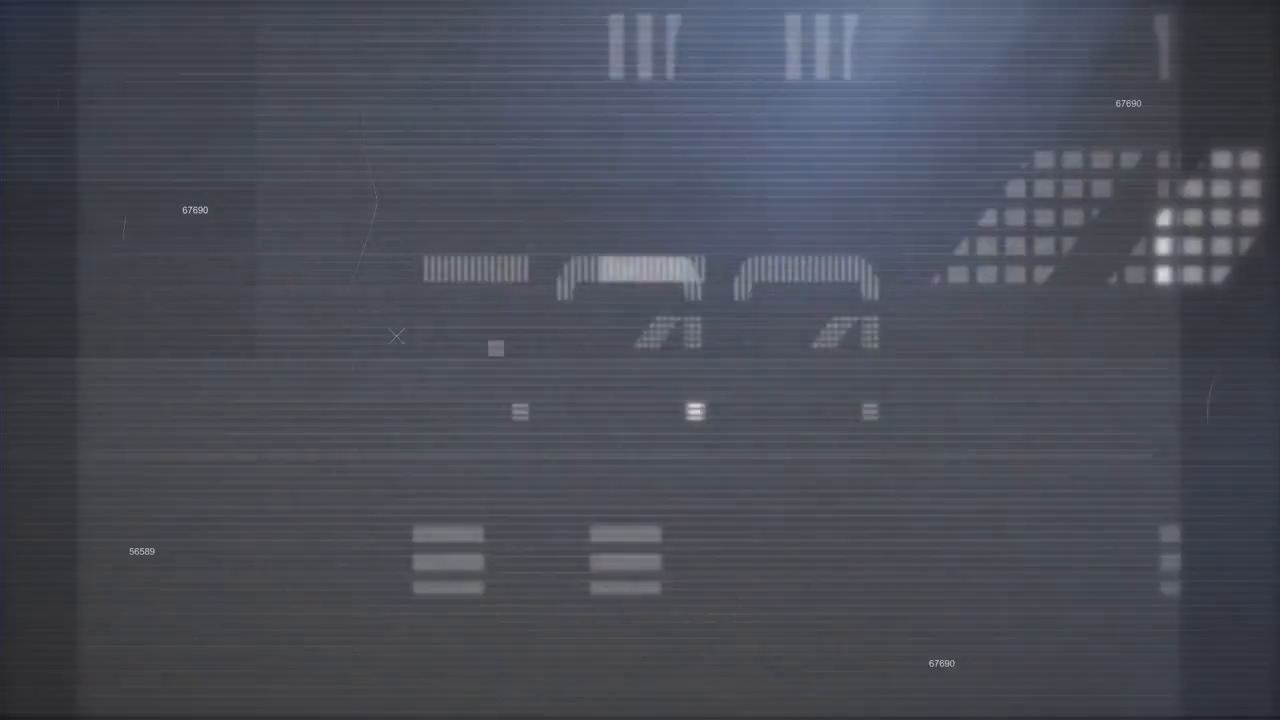

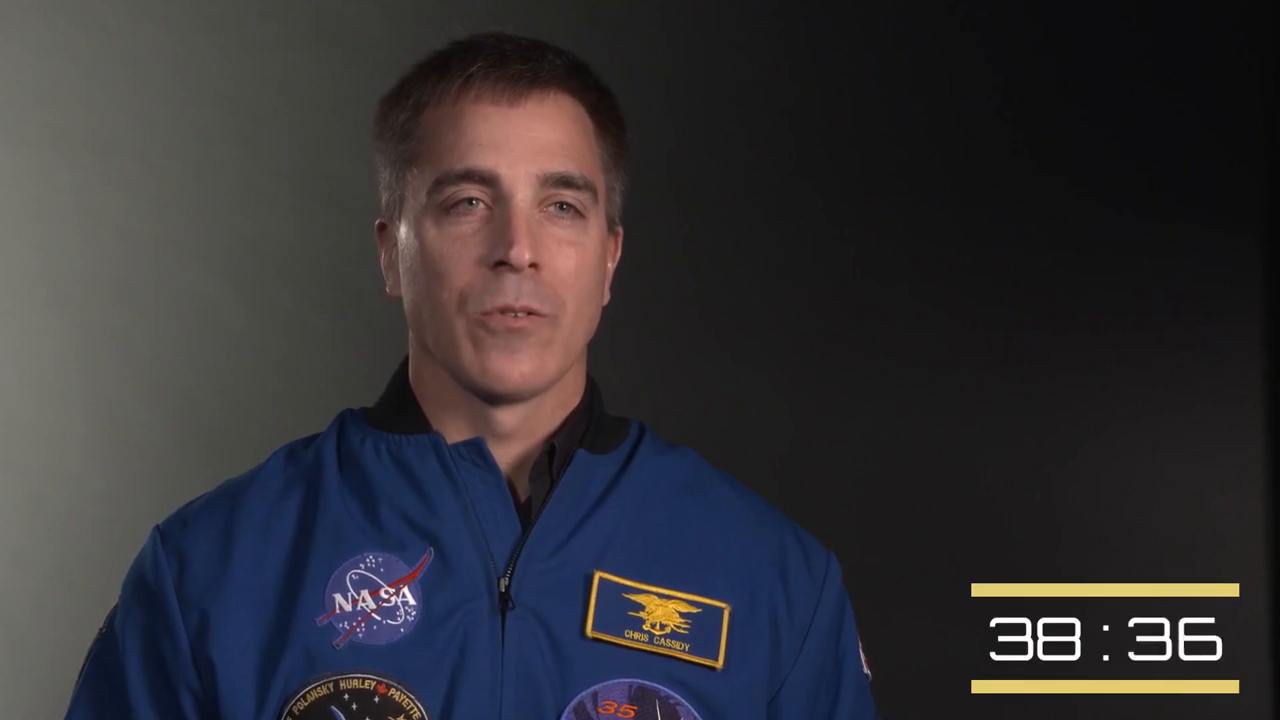

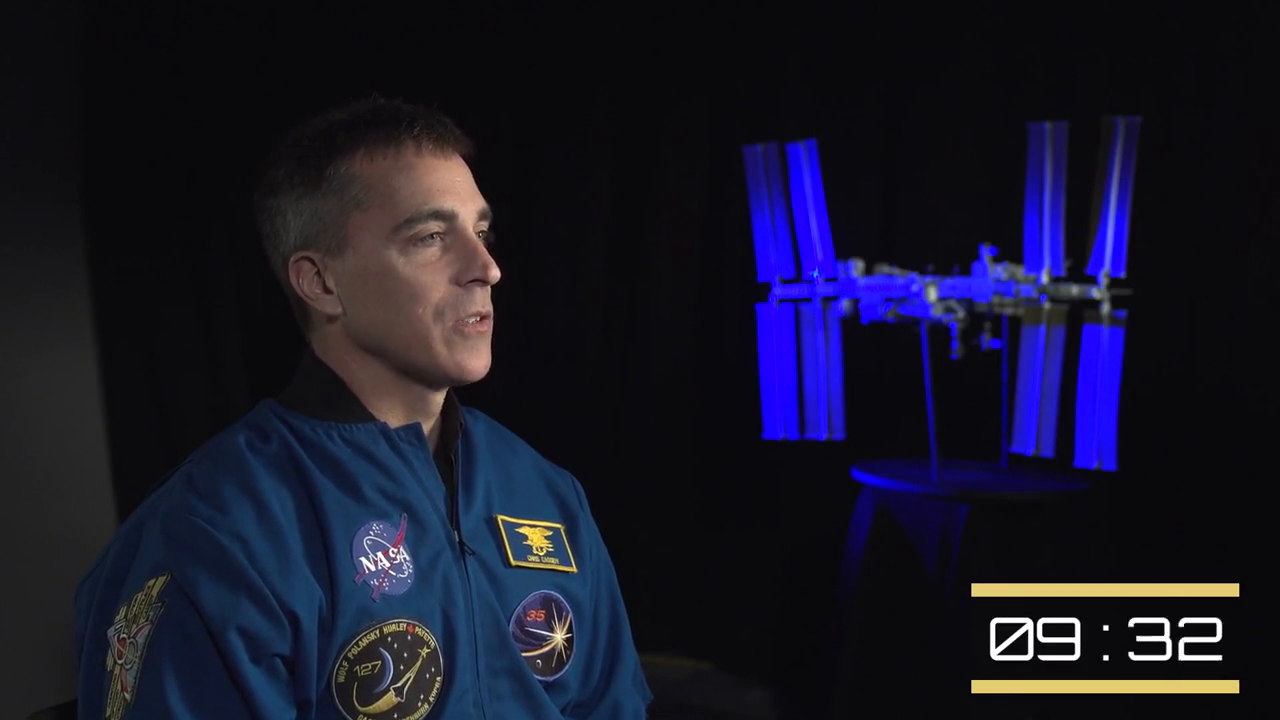

In [26]:
# =========================================
# コード11 動画から32フレームを抽出
# =========================================
import cv2
import numpy as np
from PIL import Image

def extract_video_frames(
    video_path,
    num_frames=32,
):
    cap = cv2.VideoCapture(str(video_path))

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total_frames <= 0:
        cap.release()
        raise RuntimeError(
            "動画のフレーム数を取得できませんでした。"
        )

    indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int,
    )

    frames = []

    for idx in indices:
        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(idx),
        )

        ok, frame = cap.read()

        if not ok:
            continue

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB,
        )

        frames.append(
            Image.fromarray(frame)
        )

    cap.release()

    print("total video frames:", total_frames)
    print("extracted frames:", len(frames))

    return frames


VIDEO_FRAMES = extract_video_frames(
    NASA_VIDEO_60S,
    num_frames=32,
)

display(VIDEO_FRAMES[0])
display(VIDEO_FRAMES[len(VIDEO_FRAMES)//2])
display(VIDEO_FRAMES[-1])


In [27]:
# =========================================
# コード12 32フレームをmulti-imageとして理解させる
# =========================================
@torch.inference_mode()
def gemma_video_frames_generate(
    frames,
    prompt,
    max_new_tokens=512,
):
    content = []

    for frame in frames:
        content.append({
            "type": "image",
            "image": frame,
        })

    content.append({
        "type": "text",
        "text": prompt,
    })

    messages = [
        {
            "role": "system",
            "content": "You are a helpful assistant.",
        },
        {
            "role": "user",
            "content": content,
        },
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
        enable_thinking=False,
    ).to(INPUT_DEVICE)

    input_len = inputs["input_ids"].shape[-1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=int(max_new_tokens),
        do_sample=True,
        temperature=1.0,
        top_p=0.95,
        top_k=64,
        use_cache=True,
    )

    response = processor.decode(
        outputs[0][input_len:],
        skip_special_tokens=False,
    )

    try:
        parsed = processor.parse_response(
            response,
            prefix=inputs["input_ids"],
        )
        return parsed_response_to_text(parsed)

    except Exception:
        return response.strip()


answer = gemma_video_frames_generate(
    VIDEO_FRAMES,
    prompt=(
        "これらは1本の動画から時間順に抽出したフレームです。"
        "動画全体で何が起きているか、登場人物、行動、話題を"
        "日本語で簡潔に説明してください。"
    ),
    max_new_tokens=512,
)

print(answer)


提供された一連の画像は、**宇宙飛行士であるクリス・キャッシ（Chris Cassidy）氏によるNASAのライブ配信または訓練セッションの様子**を、時間経過（動画の進行）とともに捉えたものです。

**動画全体で起きていることの概要:**

この動画は、NASAの訓練やミッション開始前の最終カウントダウンの様子を記録したものです。

1. **初期（画面最上部）:** デジタルな計測データやインターフェースが表示されており、準備段階にあることが伺えます。
2. **メインコンテンツ（画面中段以降）:** 宇宙飛行士のクリス・キャッシ氏が、宇宙飛行士のコスチュームを着用して登場します。
3. **話題:** 彼はNASAのロゴを背景に、ミッションの進捗を伝えたり、訓練状況を説明したりしています。
4. **時間表示:** 右下に「T-60 SECONDS」（60秒前）から「15:13」「09:32」といった形で具体的な時間が表示されており、これは**カウントダウンが進んでいること**を示しています。
5. **機体模型:** 彼の隣には、国際宇宙ステーション（ISS）や関連機材を模したと思われる青く発光する機体模型が配置されており、これが会話のテーマや訓練のシミュレーションの対象であることを示唆しています。

**登場人物と行動:**

* **登場人物:** クリス・キャッシ宇宙飛行士（Chris Cassidy）。
* **行動:** 宇宙飛行士の服を着てカメラに向かって話しており、時折、手のジェスチャーを交えながら（例えば、最後の方で手を叩くようなポーズ）説明を行っています。

**要約:**

クリス・キャッシ宇宙飛行士が、ISSに関連する訓練またはミッション開始に先立ち、時間（カウントダウン）が刻まれる中で進めるNASAのライブセッションの記録であり、専門的な機材模型を背景にミッションに関する情報伝達を行っている動画です。


In [28]:
# =========================================
# コード13 Gradioを用いた画像・音声UI
# 動画は固定サンプルの32フレーム実験を上のセルで行う
# =========================================
import gradio as gr
import torch

print("Gradio:", gr.__version__)


def gr_generate(prompt, image, audio):
    try:
        return gemma_generate(
            prompt=prompt,
            image_path=image,
            audio_path=audio,
            max_new_tokens=512,
        )

    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        return (
            "CUDA out of memory が発生しました。"
            "画像・音声を外すか、ランタイムを再起動してください。"
        )

    except Exception as e:
        return f"{type(e).__name__}: {e}"


with gr.Blocks(title="Gemma 4 E4B Multimodal") as demo:
    gr.Markdown("## Gemma 4 E4B — Multimodal Local Chat")

    prompt_box = gr.Textbox(
        label="質問",
        placeholder="質問を入力してください。",
        lines=3,
    )

    image_box = gr.Image(
        label="画像（任意）",
        type="filepath",
    )

    audio_box = gr.Audio(
        label="音声（任意・30秒以内推奨）",
        type="filepath",
    )

    with gr.Row():
        send_btn = gr.Button("Send", variant="primary")
        clear_btn = gr.Button("Clear")

    output_box = gr.Textbox(
        label="回答",
        lines=12,
    )

    send_btn.click(
        fn=gr_generate,
        inputs=[
            prompt_box,
            image_box,
            audio_box,
        ],
        outputs=output_box,
        queue=False,
    )

    clear_btn.click(
        lambda: ("", None, None, ""),
        outputs=[
            prompt_box,
            image_box,
            audio_box,
            output_box,
        ],
        queue=False,
    )

print("WARNING: share=Trueで一時的な公開URLが作成されます。")

demo.launch(
    share=True,
    inline=True,
    debug=False,
)


Gradio: 6.20.0
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e6c64b8af873c3f3ea.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Test media / License

このNotebookで利用するサンプル素材は、再利用条件が明確なものを利用しています。

### Image
**ISS-42 Earth from the ISS.jpg**
- NASA / Samantha Cristoforetti
- Public Domain
- via Wikimedia Commons

### Audio 1
**Recording of speaker of British English (Received Pronunciation).ogg**
- P. Roach / International Phonetic Association
- CC BY-SA 3.0
- 元音声36秒から先頭30秒を切り出し
- via Wikimedia Commons

### Audio 2
**STS-001-1-10.ogg**
- NASA
- CC0 1.0
- 約29.6秒を30秒WAVへ整形
- via Wikimedia Commons

### Video
**T - 60 Seconds with Chris Cassidy.webm**
- NASA Johnson Space Center
- Public Domain
- 元動画約94秒から先頭60秒を切り出し
- via Wikimedia Commons

## Important

このNotebookではPyTorch本体を入れ替えません。

以前発生した主な問題への対策:

- TorchAudio CUDA mismatch → torchaudioを使わない
- NumPy / SciPy binary mismatch → numpy 2.2.6 / scipy 1.16.1へ固定
- Wikimedia HTTP 429 → retry + exponential backoff
- VideoProcessor tuple error → 動画を32フレームへ明示抽出しmulti-imageとして入力
